In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [4]:
from sklearn.ensemble import RandomForestClassifier

In [5]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [6]:
dataset = pd.read_csv("/content/Churn_Modelling.csv")

In [7]:
print("First 5 Rows:")
print(dataset.head())

print("\nDataset Shape:")
print(dataset.shape)

print("\nDataset Information:")
print(dataset.info())

print("\nMissing Values:")
print(dataset.isnull().sum())


First 5 Rows:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  

In [8]:
dataset.fillna(dataset.median(numeric_only=True), inplace=True)

In [9]:
dataset.drop(
    columns=['RowNumber', 'CustomerId', 'Surname'],
    inplace=True
)

In [10]:
label_encoder = LabelEncoder()

dataset['Gender'] = label_encoder.fit_transform(
    dataset['Gender']
)

dataset['Geography'] = label_encoder.fit_transform(
    dataset['Geography']
)


In [11]:
X = dataset.drop('Exited', axis=1)
y = dataset['Exited']

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)


Feature Shape: (10000, 10)
Target Shape: (10000,)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [14]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel Training Completed!")


Model Training Completed!


In [15]:
y_pred = model.predict(X_test)

In [16]:
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:")
print(round(accuracy * 100, 2), "%")


Accuracy:
86.45 %


In [17]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)



Confusion Matrix:
[[1545   62]
 [ 209  184]]


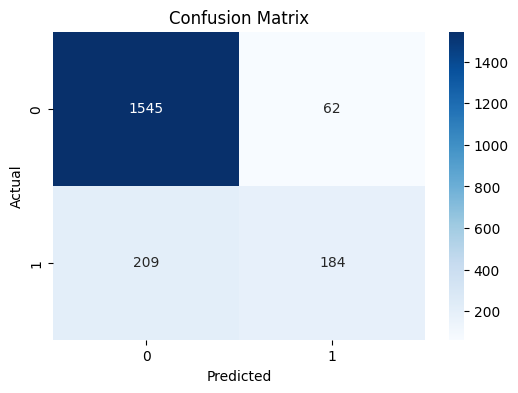

In [18]:
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [19]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.47      0.58       393

    accuracy                           0.86      2000
   macro avg       0.81      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000

